In [536]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings


import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import xgboost as xgb
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

In [537]:
warnings.filterwarnings("ignore")

In [538]:
df = pd.read_csv('House_Price.csv')
df.head()

,Flat_Price,EMI_Starts,BHK,css-11nfaq3,Unnamed: 4,HOUSE_TYPE,Unnamed: 6,Unnamed: 7,Purpose,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,6.0,BHK,Independent House,Independent,House,for sale in,"Ballygunge, Kolkata",Build Up Area,4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert
1,₹45.0 L,₹23.83 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Barrackpore, Kolkata",Build Up Area,1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert
2,₹1.35 Cr,₹67.02 K,3 BHK,3.0,BHK,Independent House,Independent,House,for sale in,"Santoshpur, Kolkata",Build Up Area,2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert
3,₹60.0 L,₹31.77 K,5 BHK,5.0,BHK,Independent House,Independent,House,for sale in,"Sarsuna, Kolkata",Build Up Area,1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert
4,₹52.0 L,₹27.54 K,4 BHK,4.0,BHK,Independent House,Independent,House,for sale in,"Madhyamgram, Kolkata",Build Up Area,900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert


In [539]:
df.shape

(3968, 15)

In [540]:
df.columns

Index(['Flat_Price', 'EMI_Starts', 'BHK', 'css-11nfaq3', 'Unnamed: 4',
       'HOUSE_TYPE', 'Unnamed: 6', 'Unnamed: 7', 'Purpose', 'Location',
       'Area_Type', 'Total_Sq.ft', 'Price_per_sq.ft', 'Owner_name',
       'Owner_type'],
      dtype='str')

In [541]:
df.drop(columns=["css-11nfaq3","Unnamed: 4","Unnamed: 6","Unnamed: 7"], inplace=True)
# Removes useless columns

In [542]:
df.columns

Index(['Flat_Price', 'EMI_Starts', 'BHK', 'HOUSE_TYPE', 'Purpose', 'Location',
       'Area_Type', 'Total_Sq.ft', 'Price_per_sq.ft', 'Owner_name',
       'Owner_type'],
      dtype='str')

In [543]:
df.tail()

,Flat_Price,EMI_Starts,BHK,HOUSE_TYPE,Purpose,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
3963,₹13.0 L,₹6.88 K,2 BHK,Independent House,for sale in,"Picnic Garden, Kolkata",Build Up Area,1500 sq.ft,₹866/sq.ft,Goutam Dey,Owner
3964,₹1.5 Cr,₹74.47 K,8 BHK,Independent House,for sale in,"Rajpur Sonarpur, Kolkata",Build Up Area,2560 sq.ft,₹5.86 K/sq.ft,Alak Kumar Roy,Owner
3965,₹50.0 L,₹26.48 K,5 BHK,Independent House,for sale in,"Amtala, Kolkata",Build Up Area,1900 sq.ft,₹2.63 K/sq.ft,Sarishma,Owner
3966,₹1.1 Cr,₹54.61 K,5 BHK,Independent House,for sale in,"Tollygunge, Kolkata",Build Up Area,2600 sq.ft,₹4.23 K/sq.ft,MEDIATOR REALTORS,Agent
3967,₹30.0 L,₹15.89 K,2 BHK,Independent House,for sale in,"Naihati, Kolkata",Build Up Area,950 sq.ft,₹3.16 K/sq.ft,S Mukherjee,Owner


In [544]:
df.shape

(3968, 11)

In [545]:
df.describe()

,Flat_Price,EMI_Starts,BHK,HOUSE_TYPE,Purpose,Location,Area_Type,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
count,3968,3968,3968,3968,3966,3966,3968,3968,3968,3958,3968
unique,283,280,19,2,1,201,2,410,720,1209,6
top,₹1.5 Cr,₹39.72 K,3 BHK,Independent House,for sale in,"Salt Lake City, Kolkata",Build Up Area,3000 sq.ft,₹5.00 K/sq.ft,Avijit Chakraborty,Owner
freq,140,205,706,3966,3966,194,3966,222,94,144,2093


In [546]:
df.drop(columns=["HOUSE_TYPE","Purpose","Area_Type"], inplace=True)
# removes columns that don't have many unique values

In [547]:
df.head()

,Flat_Price,EMI_Starts,BHK,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,₹8.5 Cr,₹4.22 Lacs,6 BHK,"Ballygunge, Kolkata",4200 sq.ft,₹20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert
1,₹45.0 L,₹23.83 K,3 BHK,"Barrackpore, Kolkata",1400 sq.ft,₹3.21 K/sq.ft,Virtual Reality,Housing Expert
2,₹1.35 Cr,₹67.02 K,3 BHK,"Santoshpur, Kolkata",2500 sq.ft,₹5.40 K/sq.ft,AveNew Properties,Housing Expert
3,₹60.0 L,₹31.77 K,5 BHK,"Sarsuna, Kolkata",1100 sq.ft,₹5.45 K/sq.ft,Ganapati Real Estate,Housing Expert
4,₹52.0 L,₹27.54 K,4 BHK,"Madhyamgram, Kolkata",900 sq.ft,₹5.78 K/sq.ft,Third Eye Consulting,Housing Expert


In [548]:
df.dtypes

Flat_Price         str
EMI_Starts         str
BHK                str
Location           str
Total_Sq.ft        str
Price_per_sq.ft    str
Owner_name         str
Owner_type         str
dtype: object

In [549]:
df["Flat_Price"]=df["Flat_Price"].str.strip("₹")
df["EMI_Starts"]=df["EMI_Starts"].str.strip("₹")
df["Price_per_sq.ft"]=df["Price_per_sq.ft"].str.strip("₹")
df.head()

,Flat_Price,EMI_Starts,BHK,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,8.5 Cr,4.22 Lacs,6 BHK,"Ballygunge, Kolkata",4200 sq.ft,20.24 K/sq.ft,Abhijit Chakraborty,Housing Expert
1,45.0 L,23.83 K,3 BHK,"Barrackpore, Kolkata",1400 sq.ft,3.21 K/sq.ft,Virtual Reality,Housing Expert
2,1.35 Cr,67.02 K,3 BHK,"Santoshpur, Kolkata",2500 sq.ft,5.40 K/sq.ft,AveNew Properties,Housing Expert
3,60.0 L,31.77 K,5 BHK,"Sarsuna, Kolkata",1100 sq.ft,5.45 K/sq.ft,Ganapati Real Estate,Housing Expert
4,52.0 L,27.54 K,4 BHK,"Madhyamgram, Kolkata",900 sq.ft,5.78 K/sq.ft,Third Eye Consulting,Housing Expert


In [550]:
df["Price_per_sq.ft"]=df["Price_per_sq.ft"].str.strip("/sq.ft")
df.head()

,Flat_Price,EMI_Starts,BHK,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,8.5 Cr,4.22 Lacs,6 BHK,"Ballygunge, Kolkata",4200 sq.ft,20.24 K,Abhijit Chakraborty,Housing Expert
1,45.0 L,23.83 K,3 BHK,"Barrackpore, Kolkata",1400 sq.ft,3.21 K,Virtual Reality,Housing Expert
2,1.35 Cr,67.02 K,3 BHK,"Santoshpur, Kolkata",2500 sq.ft,5.40 K,AveNew Properties,Housing Expert
3,60.0 L,31.77 K,5 BHK,"Sarsuna, Kolkata",1100 sq.ft,5.45 K,Ganapati Real Estate,Housing Expert
4,52.0 L,27.54 K,4 BHK,"Madhyamgram, Kolkata",900 sq.ft,5.78 K,Third Eye Consulting,Housing Expert


In [551]:
df["Location"]=df["Location"].str.strip(", Kolkata")
# Kolkata is listed in every location
df.head()

,Flat_Price,EMI_Starts,BHK,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type
0,8.5 Cr,4.22 Lacs,6 BHK,Ballygunge,4200 sq.ft,20.24 K,Abhijit Chakraborty,Housing Expert
1,45.0 L,23.83 K,3 BHK,Barrackpore,1400 sq.ft,3.21 K,Virtual Reality,Housing Expert
2,1.35 Cr,67.02 K,3 BHK,Santoshpur,2500 sq.ft,5.40 K,AveNew Properties,Housing Expert
3,60.0 L,31.77 K,5 BHK,Sarsun,1100 sq.ft,5.45 K,Ganapati Real Estate,Housing Expert
4,52.0 L,27.54 K,4 BHK,Madhyamgram,900 sq.ft,5.78 K,Third Eye Consulting,Housing Expert


In [552]:
for i in range(df["BHK"].shape[0]):
    df["Rooms"]=df['BHK'][i].split(' ')[0]
    df["Room_Type"]=df['BHK'][i].split(' ')[1]
# Splits the string into two columns where one is the number amount and the other is the room type

In [553]:
df.head()

,Flat_Price,EMI_Starts,BHK,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,Rooms,Room_Type
0,8.5 Cr,4.22 Lacs,6 BHK,Ballygunge,4200 sq.ft,20.24 K,Abhijit Chakraborty,Housing Expert,2,BHK
1,45.0 L,23.83 K,3 BHK,Barrackpore,1400 sq.ft,3.21 K,Virtual Reality,Housing Expert,2,BHK
2,1.35 Cr,67.02 K,3 BHK,Santoshpur,2500 sq.ft,5.40 K,AveNew Properties,Housing Expert,2,BHK
3,60.0 L,31.77 K,5 BHK,Sarsun,1100 sq.ft,5.45 K,Ganapati Real Estate,Housing Expert,2,BHK
4,52.0 L,27.54 K,4 BHK,Madhyamgram,900 sq.ft,5.78 K,Third Eye Consulting,Housing Expert,2,BHK


In [554]:
df.drop("BHK",axis=1,inplace=True) # no longer needed after the split
df.head()

,Flat_Price,EMI_Starts,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,Rooms,Room_Type
0,8.5 Cr,4.22 Lacs,Ballygunge,4200 sq.ft,20.24 K,Abhijit Chakraborty,Housing Expert,2,BHK
1,45.0 L,23.83 K,Barrackpore,1400 sq.ft,3.21 K,Virtual Reality,Housing Expert,2,BHK
2,1.35 Cr,67.02 K,Santoshpur,2500 sq.ft,5.40 K,AveNew Properties,Housing Expert,2,BHK
3,60.0 L,31.77 K,Sarsun,1100 sq.ft,5.45 K,Ganapati Real Estate,Housing Expert,2,BHK
4,52.0 L,27.54 K,Madhyamgram,900 sq.ft,5.78 K,Third Eye Consulting,Housing Expert,2,BHK


In [555]:
df["Total_Sq.ft"]=df["Total_Sq.ft"].str.strip("sq.ft")
df.head()

,Flat_Price,EMI_Starts,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,Rooms,Room_Type
0,8.5 Cr,4.22 Lacs,Ballygunge,4200,20.24 K,Abhijit Chakraborty,Housing Expert,2,BHK
1,45.0 L,23.83 K,Barrackpore,1400,3.21 K,Virtual Reality,Housing Expert,2,BHK
2,1.35 Cr,67.02 K,Santoshpur,2500,5.40 K,AveNew Properties,Housing Expert,2,BHK
3,60.0 L,31.77 K,Sarsun,1100,5.45 K,Ganapati Real Estate,Housing Expert,2,BHK
4,52.0 L,27.54 K,Madhyamgram,900,5.78 K,Third Eye Consulting,Housing Expert,2,BHK


In [556]:
df.isna().sum()

Flat_Price          0
EMI_Starts          0
Location            2
Total_Sq.ft         0
Price_per_sq.ft     0
Owner_name         10
Owner_type          0
Rooms               0
Room_Type           0
dtype: int64

In [557]:
df.dropna(inplace=True)
df.isna().sum()

Flat_Price         0
EMI_Starts         0
Location           0
Total_Sq.ft        0
Price_per_sq.ft    0
Owner_name         0
Owner_type         0
Rooms              0
Room_Type          0
dtype: int64

In [558]:
df.reset_index(drop=True,inplace=True) # Replaces the old index after dropping the na values
df["Flat_Price"][:]

0        8.5 Cr
1        45.0 L
2       1.35 Cr
3        60.0 L
4        52.0 L
         ...   
3951     13.0 L
3952     1.5 Cr
3953     50.0 L
3954     1.1 Cr
3955     30.0 L
Name: Flat_Price, Length: 3956, dtype: str

In [559]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3956 entries, 0 to 3955
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Flat_Price       3956 non-null   str  
 1   EMI_Starts       3956 non-null   str  
 2   Location         3956 non-null   str  
 3   Total_Sq.ft      3956 non-null   str  
 4   Price_per_sq.ft  3956 non-null   str  
 5   Owner_name       3956 non-null   str  
 6   Owner_type       3956 non-null   str  
 7   Rooms            3956 non-null   str  
 8   Room_Type        3956 non-null   str  
dtypes: str(9)
memory usage: 278.3 KB


In [560]:
prices = []
for i in range(len(df)):
    price_str = df["Flat_Price"].iloc[i]
    parts = price_str.split()
    num = float(parts[0])
    unit = parts[1]
    if unit == "Cr":
        prices.append(num * 10000000)
    else:
        prices.append(num * 100000)
df["Flat_Price"] = prices
# Splits the price into numeric values and converts the crores into lakhs

In [561]:
df.head()

,Flat_Price,EMI_Starts,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,Rooms,Room_Type
0,85000000.0,4.22 Lacs,Ballygunge,4200,20.24 K,Abhijit Chakraborty,Housing Expert,2,BHK
1,4500000.0,23.83 K,Barrackpore,1400,3.21 K,Virtual Reality,Housing Expert,2,BHK
2,13500000.0,67.02 K,Santoshpur,2500,5.40 K,AveNew Properties,Housing Expert,2,BHK
3,6000000.0,31.77 K,Sarsun,1100,5.45 K,Ganapati Real Estate,Housing Expert,2,BHK
4,5200000.0,27.54 K,Madhyamgram,900,5.78 K,Third Eye Consulting,Housing Expert,2,BHK


In [562]:
df.head()

,Flat_Price,EMI_Starts,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,Rooms,Room_Type
0,85000000.0,4.22 Lacs,Ballygunge,4200,20.24 K,Abhijit Chakraborty,Housing Expert,2,BHK
1,4500000.0,23.83 K,Barrackpore,1400,3.21 K,Virtual Reality,Housing Expert,2,BHK
2,13500000.0,67.02 K,Santoshpur,2500,5.40 K,AveNew Properties,Housing Expert,2,BHK
3,6000000.0,31.77 K,Sarsun,1100,5.45 K,Ganapati Real Estate,Housing Expert,2,BHK
4,5200000.0,27.54 K,Madhyamgram,900,5.78 K,Third Eye Consulting,Housing Expert,2,BHK


In [563]:
df["EMI_Starts"].str.split(" ")

0       [4.22, Lacs]
1         [23.83, K]
2         [67.02, K]
3         [31.77, K]
4         [27.54, K]
            ...     
3951       [6.88, K]
3952      [74.47, K]
3953      [26.48, K]
3954      [54.61, K]
3955      [15.89, K]
Name: EMI_Starts, Length: 3956, dtype: object

In [564]:
df.head()

,Flat_Price,EMI_Starts,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,Rooms,Room_Type
0,85000000.0,4.22 Lacs,Ballygunge,4200,20.24 K,Abhijit Chakraborty,Housing Expert,2,BHK
1,4500000.0,23.83 K,Barrackpore,1400,3.21 K,Virtual Reality,Housing Expert,2,BHK
2,13500000.0,67.02 K,Santoshpur,2500,5.40 K,AveNew Properties,Housing Expert,2,BHK
3,6000000.0,31.77 K,Sarsun,1100,5.45 K,Ganapati Real Estate,Housing Expert,2,BHK
4,5200000.0,27.54 K,Madhyamgram,900,5.78 K,Third Eye Consulting,Housing Expert,2,BHK


In [565]:
emi_list = []
for i in range(len(df)):
    emi_str = df["EMI_Starts"].iloc[i]
    parts = emi_str.split()
    if len(parts) == 2:
        num = float(parts[0])
        unit = parts[1]
        if unit == "K":
            emi_list.append(num * 1000)
        elif unit == "Lacs" or unit == "Lac":
            emi_list.append(num * 100000)
        elif unit == "Cr":
            emi_list.append(num * 10000000)
        else:
            emi_list.append(num)
    else:
        emi_list.append(float(emi_str.replace(',', '')))
df["EMI_Starts"] = emi_list

In [566]:
df.head()

,Flat_Price,EMI_Starts,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,Rooms,Room_Type
0,85000000.0,422000.0,Ballygunge,4200,20.24 K,Abhijit Chakraborty,Housing Expert,2,BHK
1,4500000.0,23830.0,Barrackpore,1400,3.21 K,Virtual Reality,Housing Expert,2,BHK
2,13500000.0,67020.0,Santoshpur,2500,5.40 K,AveNew Properties,Housing Expert,2,BHK
3,6000000.0,31770.0,Sarsun,1100,5.45 K,Ganapati Real Estate,Housing Expert,2,BHK
4,5200000.0,27540.0,Madhyamgram,900,5.78 K,Third Eye Consulting,Housing Expert,2,BHK


In [567]:
df["Price_per_sq.ft"].unique()

<StringArray>
['20.24 K',  '3.21 K',  '5.40 K',  '5.45 K',  '5.78 K',  '2.67 K',  '3.00 K',
  '3.42 K',  '5.10 K',  '7.14 K',
 ...
  '2.10 K',  '4.78 K',  '1.03 K', '12.86 K',  '2.23 K', '15.15 K',  '7.34 K',
  '2.21 K',  '7.42 K',     '866']
Length: 718, dtype: str

In [568]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3956 entries, 0 to 3955
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Flat_Price       3956 non-null   float64
 1   EMI_Starts       3956 non-null   float64
 2   Location         3956 non-null   str    
 3   Total_Sq.ft      3956 non-null   str    
 4   Price_per_sq.ft  3956 non-null   str    
 5   Owner_name       3956 non-null   str    
 6   Owner_type       3956 non-null   str    
 7   Rooms            3956 non-null   str    
 8   Room_Type        3956 non-null   str    
dtypes: float64(2), str(7)
memory usage: 278.3 KB


In [569]:
price_list = []
for i in range(len(df)):
    price_str = df["Price_per_sq.ft"].iloc[i]
    parts = price_str.split()
    if len(parts) == 2:
        num = float(parts[0])
        unit = parts[1]
        if unit == "K":
            price_list.append(num * 1000)
        else:
            price_list.append(num * 100000)
    else:
        price_list.append(float(price_str.replace(',', '')))
df["Price_per_sq.ft"] = price_list

In [570]:
df.head()

,Flat_Price,EMI_Starts,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,Rooms,Room_Type
0,85000000.0,422000.0,Ballygunge,4200,20240.0,Abhijit Chakraborty,Housing Expert,2,BHK
1,4500000.0,23830.0,Barrackpore,1400,3210.0,Virtual Reality,Housing Expert,2,BHK
2,13500000.0,67020.0,Santoshpur,2500,5400.0,AveNew Properties,Housing Expert,2,BHK
3,6000000.0,31770.0,Sarsun,1100,5450.0,Ganapati Real Estate,Housing Expert,2,BHK
4,5200000.0,27540.0,Madhyamgram,900,5780.0,Third Eye Consulting,Housing Expert,2,BHK


In [571]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3956 entries, 0 to 3955
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Flat_Price       3956 non-null   float64
 1   EMI_Starts       3956 non-null   float64
 2   Location         3956 non-null   str    
 3   Total_Sq.ft      3956 non-null   str    
 4   Price_per_sq.ft  3956 non-null   float64
 5   Owner_name       3956 non-null   str    
 6   Owner_type       3956 non-null   str    
 7   Rooms            3956 non-null   str    
 8   Room_Type        3956 non-null   str    
dtypes: float64(3), str(6)
memory usage: 278.3 KB


In [572]:
df["Flat_Price"]=df["Flat_Price"].astype(float)
df["EMI_Starts"]=df["EMI_Starts"].astype(float)
df["Price_per_sq.ft"]=df["Price_per_sq.ft"].astype(float)

df["Rooms"]=df["Rooms"].astype(int)

In [573]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3956 entries, 0 to 3955
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Flat_Price       3956 non-null   float64
 1   EMI_Starts       3956 non-null   float64
 2   Location         3956 non-null   str    
 3   Total_Sq.ft      3956 non-null   str    
 4   Price_per_sq.ft  3956 non-null   float64
 5   Owner_name       3956 non-null   str    
 6   Owner_type       3956 non-null   str    
 7   Rooms            3956 non-null   int64  
 8   Room_Type        3956 non-null   str    
dtypes: float64(3), int64(1), str(5)
memory usage: 278.3 KB


In [574]:
df['Room_Type'].unique()

<StringArray>
['BHK']
Length: 1, dtype: str

In [575]:
df['Owner_type'].unique()

<StringArray>
['Housing Expert', 'Housing Prime Agent', 'Verified Owner', 'Owner', 'Agent']
Length: 5, dtype: str

In [576]:
df.drop(columns=['Room_Type'], inplace=True) # Unnecessary column since there is one value
df.head()

,Flat_Price,EMI_Starts,Location,Total_Sq.ft,Price_per_sq.ft,Owner_name,Owner_type,Rooms
0,85000000.0,422000.0,Ballygunge,4200,20240.0,Abhijit Chakraborty,Housing Expert,2
1,4500000.0,23830.0,Barrackpore,1400,3210.0,Virtual Reality,Housing Expert,2
2,13500000.0,67020.0,Santoshpur,2500,5400.0,AveNew Properties,Housing Expert,2
3,6000000.0,31770.0,Sarsun,1100,5450.0,Ganapati Real Estate,Housing Expert,2
4,5200000.0,27540.0,Madhyamgram,900,5780.0,Third Eye Consulting,Housing Expert,2


In [577]:
df.drop(columns=['Owner_name'], inplace=True) # Owner name is not necessary for prediction
df.head()

,Flat_Price,EMI_Starts,Location,Total_Sq.ft,Price_per_sq.ft,Owner_type,Rooms
0,85000000.0,422000.0,Ballygunge,4200,20240.0,Housing Expert,2
1,4500000.0,23830.0,Barrackpore,1400,3210.0,Housing Expert,2
2,13500000.0,67020.0,Santoshpur,2500,5400.0,Housing Expert,2
3,6000000.0,31770.0,Sarsun,1100,5450.0,Housing Expert,2
4,5200000.0,27540.0,Madhyamgram,900,5780.0,Housing Expert,2


In [578]:
df["Total_Sq.ft"]=df["Total_Sq.ft"].astype(int)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3956 entries, 0 to 3955
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Flat_Price       3956 non-null   float64
 1   EMI_Starts       3956 non-null   float64
 2   Location         3956 non-null   str    
 3   Total_Sq.ft      3956 non-null   int64  
 4   Price_per_sq.ft  3956 non-null   float64
 5   Owner_type       3956 non-null   str    
 6   Rooms            3956 non-null   int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 216.5 KB


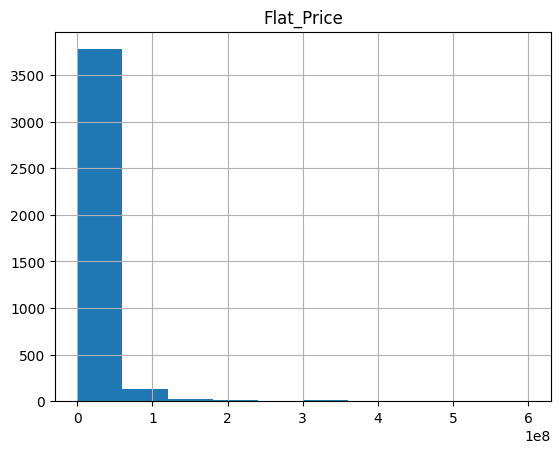

In [579]:
df.hist(column="Flat_Price")
plt.show()

<Axes: >

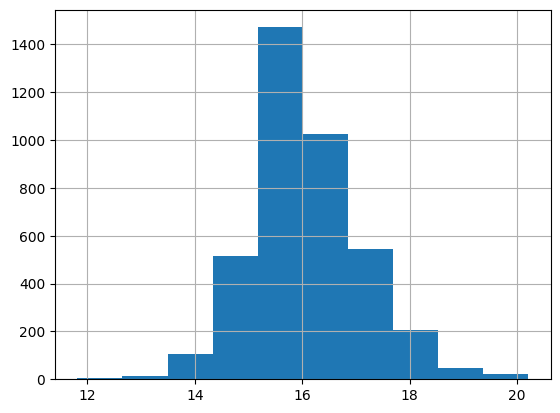

In [580]:
df['Flat_Price'] = np.log(df['Flat_Price']+1)
df['Flat_Price'].hist()

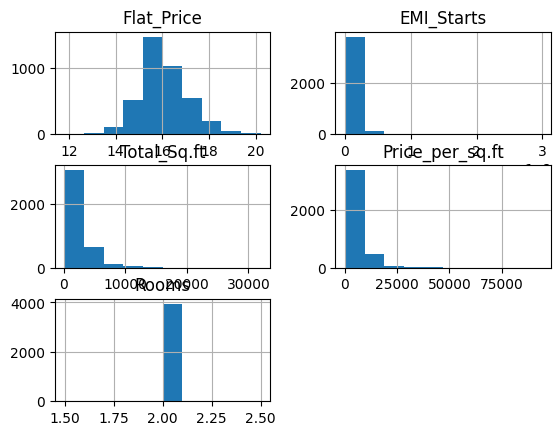

In [581]:
df.hist()
plt.show()

<Axes: >

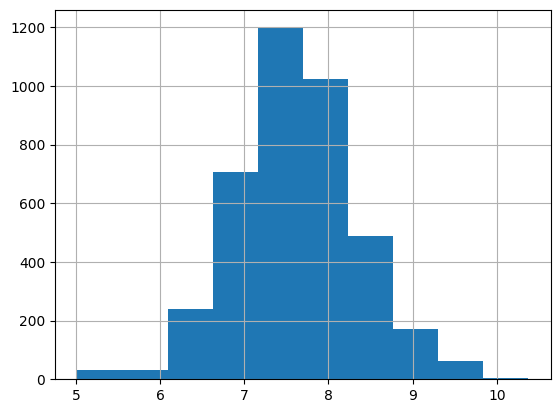

In [582]:
df['Total_Sq.ft'] = np.log(df['Total_Sq.ft']+1)
df['Total_Sq.ft'].hist()

<Axes: >

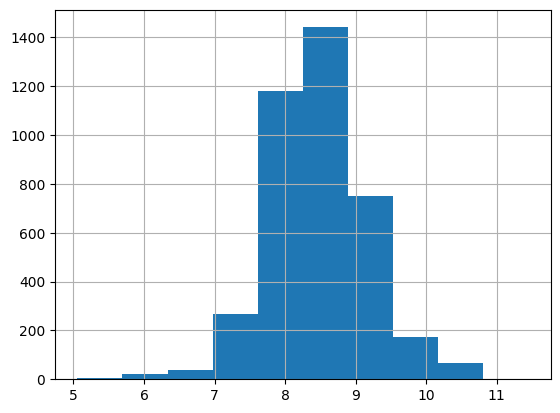

In [583]:
df['Price_per_sq.ft'] = np.log(df['Price_per_sq.ft']+1)
df['Price_per_sq.ft'].hist()

<Axes: >

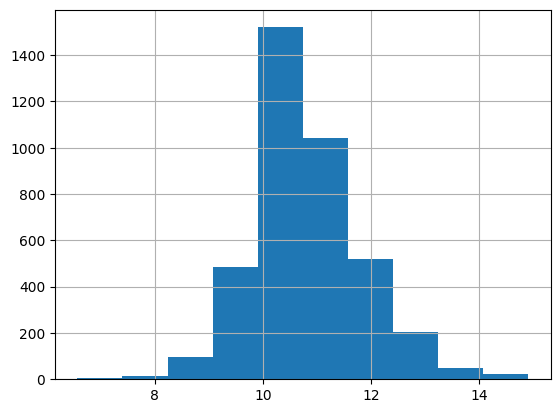

In [584]:
df['EMI_Starts'] = np.log(df['EMI_Starts']+1)
df['EMI_Starts'].hist()

In [585]:
df[['EMI_Starts', 'Flat_Price']].corr()

,EMI_Starts,Flat_Price
EMI_Starts,1.000000,0.999777
Flat_Price,0.999777,1.000000


In [586]:
df.drop(columns=['EMI_Starts'], inplace=True) # EMI starts is highly correlated with flat price so it is not needed
df.head()

,Flat_Price,Location,Total_Sq.ft,Price_per_sq.ft,Owner_type,Rooms
0,18.258162,Ballygunge,8.343078,9.915466,Housing Expert,2
1,15.319588,Barrackpore,7.244942,8.074338,Housing Expert,2
2,16.418200,Santoshpur,7.824446,8.594339,Housing Expert,2
3,15.607270,Sarsun,7.003974,8.603554,Housing Expert,2
4,15.464169,Madhyamgram,6.803505,8.662332,Housing Expert,2


In [587]:
target = 'Flat_Price'
num_features = []
cat_features = []

for col in df.columns:
    if col == target: continue
    if df[col].dtype == 'str':
        cat_features.append(col)
    else:
        num_features.append(col)

In [588]:
print('Numeric Features: ', num_features)
print('Categorical Features: ', cat_features)

Numeric Features:  ['Total_Sq.ft', 'Price_per_sq.ft', 'Rooms']
Categorical Features:  ['Location', 'Owner_type']


In [589]:
X = df.drop(columns=[target])
y=df[target]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X["Location"] = le.fit_transform(X["Location"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [590]:
X_train

,Location,Total_Sq.ft,Price_per_sq.ft,Owner_type,Rooms
3366,193,6.908755,9.305741,Owner,2
1612,88,7.650169,7.669028,Owner,2
3346,18,8.243019,7.714677,Agent,2
1117,183,9.392745,9.615872,Housing Prime Agent,2
2651,133,5.955837,8.394121,Owner,2
...,...,...,...,...,...
1130,18,6.398595,8.208219,Housing Prime Agent,2
1294,74,8.412055,7.890208,Owner,2
860,149,8.006701,9.335298,Housing Prime Agent,2
3507,65,6.957497,7.775276,Owner,2


In [591]:
df[cat_features].nunique() # Shows the amount of unique values

Location      200
Owner_type      5
dtype: int64

In [592]:
X_train = pd.get_dummies(X_train, columns=["Owner_type"], dtype=int)
X_test = pd.get_dummies(X_test, columns=["Owner_type"], dtype=int)


In [593]:
X_train.head()

,Location,Total_Sq.ft,Price_per_sq.ft,Rooms,Owner_type_Agent,Owner_type_Housing Expert,Owner_type_Housing Prime Agent,Owner_type_Owner,Owner_type_Verified Owner
3366,193,6.908755,9.305741,2,0,0,0,1,0
1612,88,7.650169,7.669028,2,0,0,0,1,0
3346,18,8.243019,7.714677,2,1,0,0,0,0
1117,183,9.392745,9.615872,2,0,0,1,0,0
2651,133,5.955837,8.394121,2,0,0,0,1,0


In [594]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

In [ ]:
from sklearn.metrics import r2_score
loss_hist=[]
scores = []
for k in range(1, 9, 1):
    knn = KNeighborsRegressor (n_neighbors = k)
    knn.fit (X_train, y_train)
    y_pred = knn.predict (X_test)
    rmse_score = np.sqrt(mean_squared_error(y_pred, y_test))
    r2 = r2_score(y_test, y_pred)
    print("k=%d, RMSE=%.2f, R2=%.2f" % (k, rmse_score, r2))
    loss_hist.append (rmse_score)
    scores.append (rmse_score)
#m = max (scores)
#print('max accuracy: ', m, ' for k=', scores.index(m)) 

k=1, RMSE=0.18, R2=0.97
k=2, RMSE=0.25, R2=0.94
k=3, RMSE=0.30, R2=0.91
k=4, RMSE=0.32, R2=0.89
k=5, RMSE=0.34, R2=0.88
k=6, RMSE=0.36, R2=0.87
k=7, RMSE=0.37, R2=0.85
k=8, RMSE=0.39, R2=0.84


In [684]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print('MSE Train = ', mse_train)
print('MSE Test = ', mse_test)
print('RMSE = ', rmse)
print('R^2 = ', knn.score(X_test, y_test))

MSE Train =  0.12518491344962746
MSE Test =  0.14988996081131453
RMSE =  0.387156248575836
R^2 =  0.8439216685335844


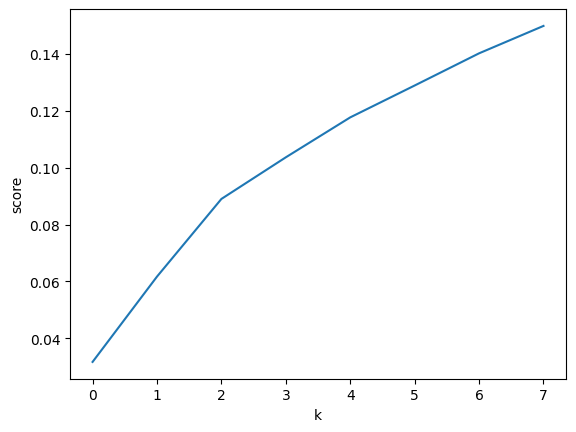

In [678]:
plt.plot(loss_hist)
plt.xlabel('k')
plt.ylabel('score')
plt.show()

In [596]:
X_train.shape, X_test.shape

((3164, 9), (792, 9))

In [685]:
from sklearn.linear_model import LinearRegression
lin = LinearRegression()
lin.fit(X_train, y_train)

y_train_pred = lin.predict(X_train)
y_test_pred = lin.predict(X_test)

mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print('MSE Train = ', mse_train)
print('MSE Test = ', mse_test)
print('RMSE = ', rmse)
print('R^2 = ', lin.score(X_test, y_test))


MSE Train =  7.8163487339179e-07
MSE Test =  7.374844329191541e-07
RMSE =  0.0008587691383131756
R^2 =  0.9999992320677172


In [659]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print ('MSE Train: ', mse_train)
print ('MSE Test: ', mse_test)
print('RMSE = ', rmse)
print('R^2 Score: ', model.score(X_test, y_test))

MSE Train:  0.00037613494883798136
MSE Test:  0.0013160652636127652
RMSE =  0.03627761380814297
R^2 Score:  0.9986295995453347


In [654]:
# Get feature importance
feature_names = X_train.columns
feature_importance = model.feature_importances_
# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
'Feature': feature_names,
'Importance': feature_importance }).sort_values(by='Importance', ascending=False)


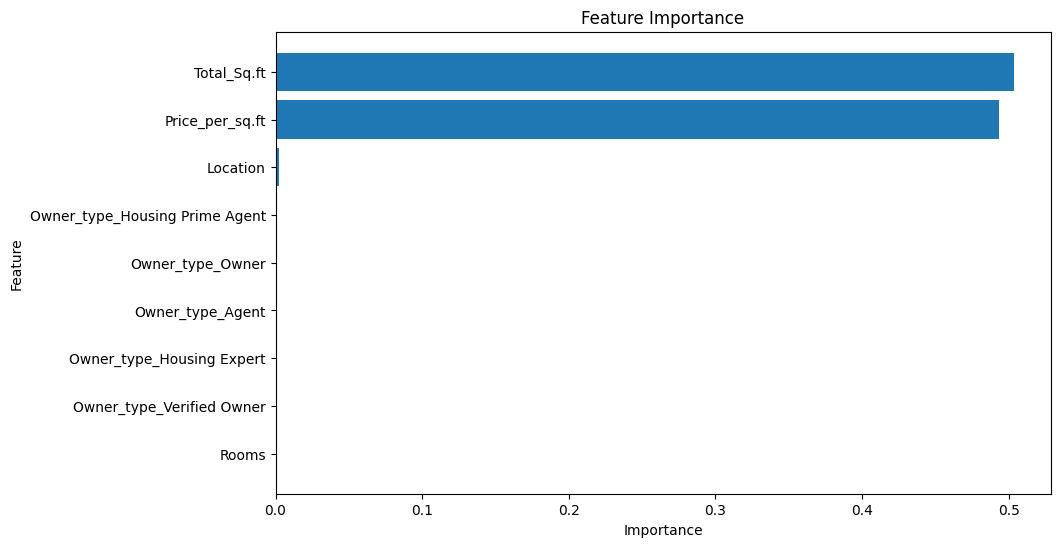

In [655]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

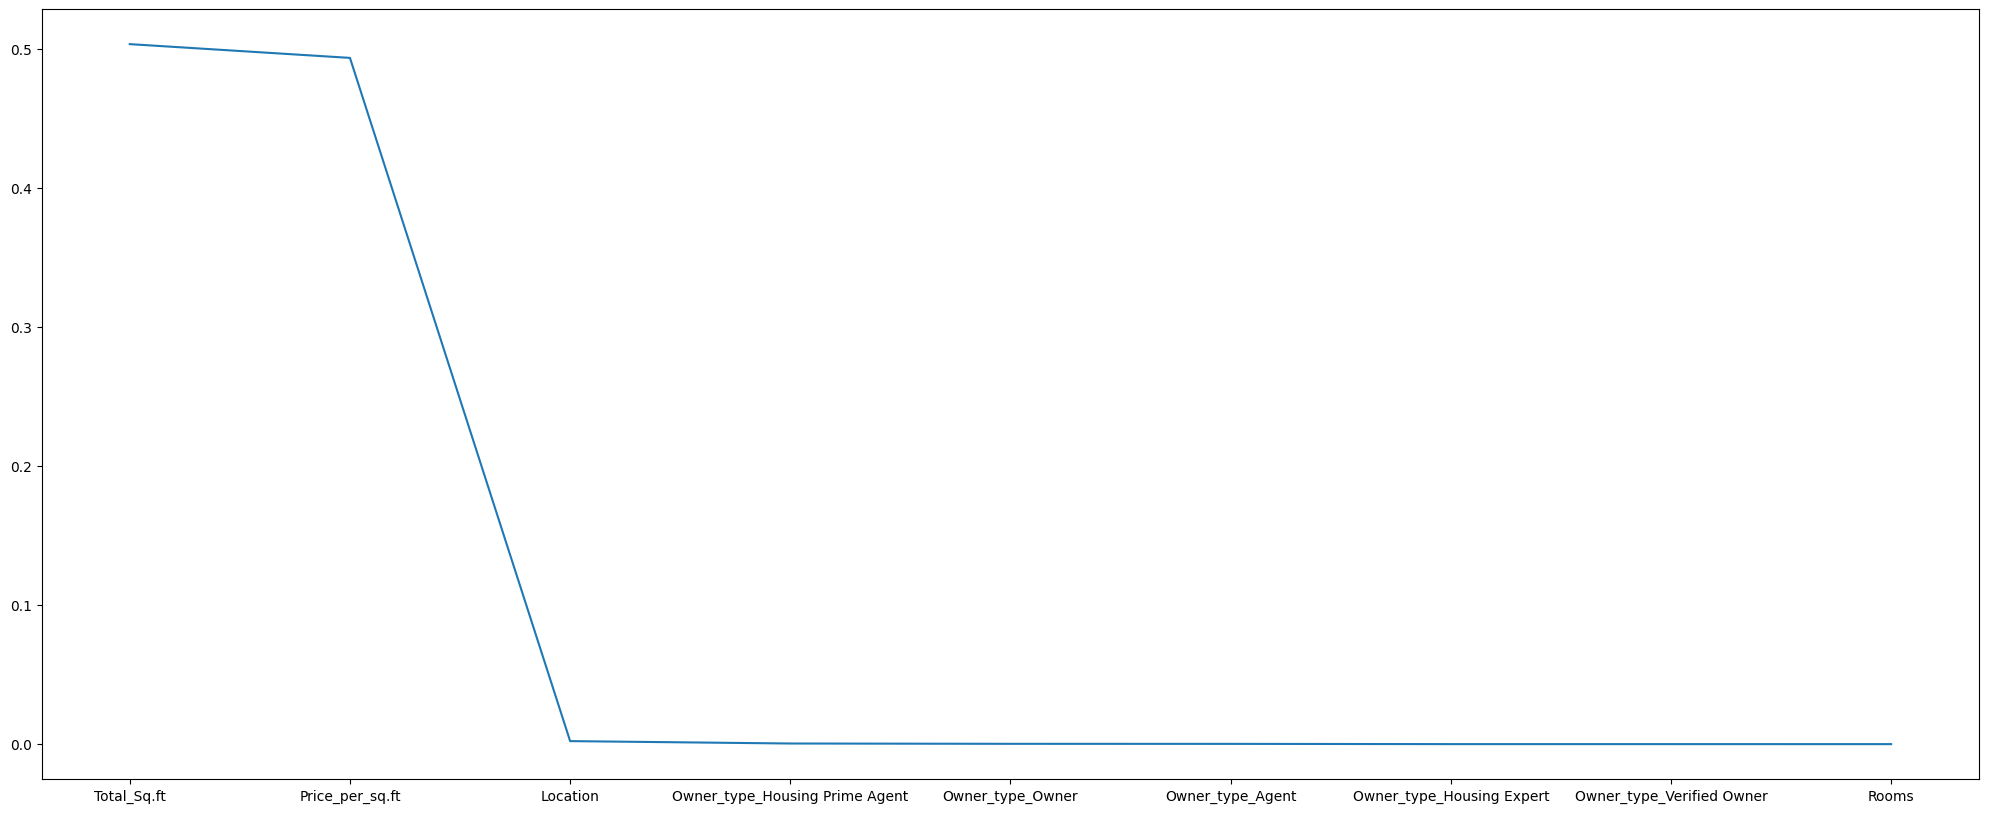

In [656]:
plt.figure(figsize=(25, 10))
plt.plot (feature_importance_df.loc[:, 'Feature'], feature_importance_df.loc[:, 'Importance'])
plt.show()

In [ ]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=50, learning_rate=0.1, max_depth=5, random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

print ('MSE Train: ', mse_train)
print ('MSE Test: ', mse_test)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
print('RMSE = ', rmse)
print('R^2 Score: ', xgb.score(X_test, y_test))

MSE Train:  0.000772480375995766
MSE Test:  0.0015124940991273449
RMSE =  0.03889079710069395
R^2 Score:  0.9984250609309201


In [692]:
feature_names = X_train.columns
feature_importance = model.feature_importances_
feature_importance_df = pd.DataFrame({
'Feature': feature_names,
'Importance': feature_importance }).sort_values(by='Importance', ascending=False)

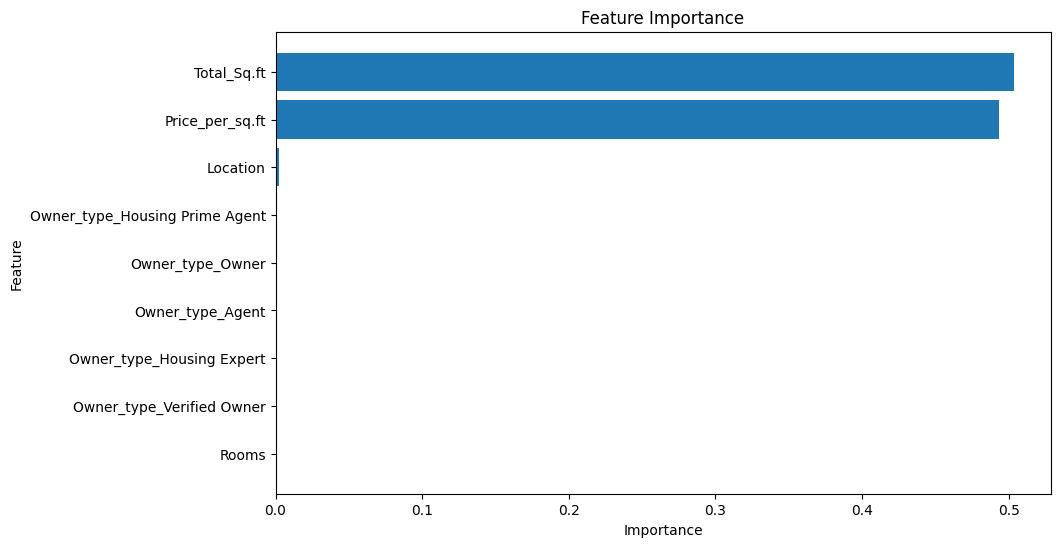

In [693]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.show()

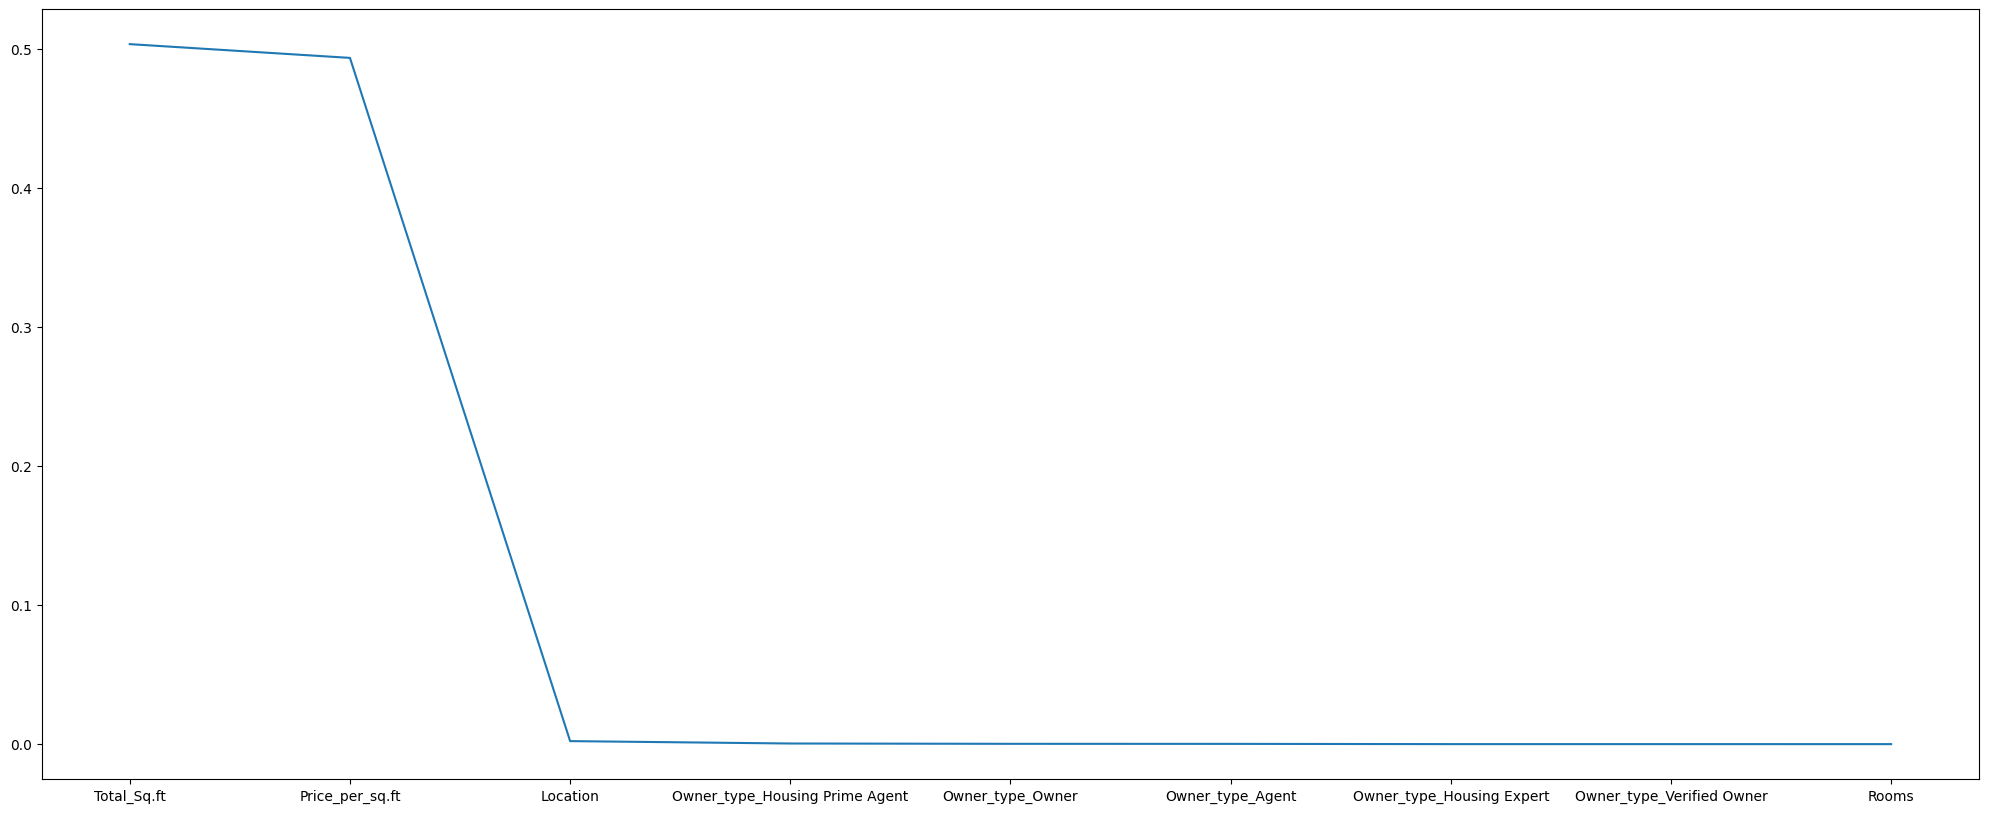

In [694]:
plt.figure(figsize=(25, 10))
plt.plot (feature_importance_df.loc[:, 'Feature'], feature_importance_df.loc[:, 'Importance'])
plt.show()

In [606]:
print(len(model.estimators_))

100


In [696]:
import torch
import random
random.seed(42)
X = torch.tensor(X_train.values, dtype=torch.float32)
y = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)


In [697]:

class simpleNN(nn.Module):
    def __init__(self):
        super(simpleNN, self).__init__()
        self.layer1 = nn.Linear(9, 2)
        self.layer2 = nn.Linear(2, 1)

    def forward(self, X):
        z1 = self.layer1(X)
        a1 = F.relu(z1)
        z2 = self.layer2(a1)
        return z2

In [698]:
model = simpleNN()

criterion = nn.MSELoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)

In [699]:
for epoch in range(1000):
    optimizer.zero_grad()  #reset all gradients before any calculation
    # Forward prop
    yp = model(X)


    #Compute the loss
    loss = criterion(yp, y)

    #Compute the gradient
    loss.backward()

    # Update weights
    optimizer.step()
    
    if (epoch +1) % 10 == 0:
        print('Epoch = ', epoch, ' loss = ', loss.item()) # y and y hat is too far

Epoch =  9  loss =  1984.38623046875
Epoch =  19  loss =  1325.142822265625
Epoch =  29  loss =  885.027587890625
Epoch =  39  loss =  591.2034301757812
Epoch =  49  loss =  395.0442810058594
Epoch =  59  loss =  264.0869445800781
Epoch =  69  loss =  176.6588897705078
Epoch =  79  loss =  118.29127502441406
Epoch =  89  loss =  79.32463073730469
Epoch =  99  loss =  53.31022262573242
Epoch =  109  loss =  35.94278335571289
Epoch =  119  loss =  24.348173141479492
Epoch =  129  loss =  16.607511520385742
Epoch =  139  loss =  11.439788818359375
Epoch =  149  loss =  7.989776134490967
Epoch =  159  loss =  5.6865105628967285
Epoch =  169  loss =  4.148843765258789
Epoch =  179  loss =  3.1222798824310303
Epoch =  189  loss =  2.4369430541992188
Epoch =  199  loss =  1.9794034957885742
Epoch =  209  loss =  1.6739486455917358
Epoch =  219  loss =  1.470025897026062
Epoch =  229  loss =  1.3338874578475952
Epoch =  239  loss =  1.2429989576339722
Epoch =  249  loss =  1.1823211908340454
E

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2 = r2_score(y_test, y_pred)

print("MSE:", mse)
print("RMSE:", rmse)
print("R2:", r2)

MSE: 0.14988996081131453
RMSE: 0.03889079710069395
R2: 0.8439216685335844


In [701]:
model.eval()

with torch.no_grad():
    y_pred = model(X)
    eval_loss = criterion(y_pred, y)
print('eval loss=', eval_loss)

eval loss= tensor(1.0604)
